# The validation ladder

This notebook re-runs the evidence behind AtiSim's validation claim, from the bottom up. Each
rung rests on the one below it: a model that gets a hand-derived answer wrong has no business
being compared with a published table, and one that disagrees with its own source data has no
business being flown through a recorded encounter.

| Rung | Question | Checked against |
|---|---|---|
| 1 | Does the model give the answers you can work out by hand? | closed-form cases in `scripts/sanity.py` |
| 2 | Does it reproduce its own source data? | NASA CR-2144's tabulated modes and drag polar; JSBSim, an independent engine, fed the same coefficients |
| 3 | Does it reproduce a real encounter? | the Hannibal clear-air-turbulence encounter, and the load NASA TM-102186 recorded |
| 4 | Does it reproduce the published orderings, and the mechanism behind them? | TM-102186 Fig. 8; Wingrove & Bach Fig. 8 |

**Every number below is computed when the notebook runs; none is typed in.** The assertions are
bands and orderings, because that is the form the claim takes: AtiSim is validated as a
*comparative and mechanistic* tool, not as an absolute-load predictor
([`docs/PROJECT.md`](../docs/PROJECT.md) §1). Rung 3 shows why.

The solver itself — the integrator's order of accuracy, the trim solve's convergence,
closed-form rigid-body motion — is checked in [`solver-validation.ipynb`](solver-validation.ipynb).
That notebook asks whether the equations are solved correctly; this one asks whether they are
the right equations.

The whole notebook takes a few minutes to run, most of it in rung 4. CI runs it on every pull
request.

In [1]:
import io
import os
import re
import subprocess
import sys
import tempfile
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
from IPython.display import Image, display

import atisim  # enables float64 before any array is made
from atisim import checks, cr2144_mach, jsbsim_ref, trim, validation, wind
from atisim.aircraft import CRUISE, REGISTRY
from atisim.panel import ALPHA_LINEAR_DEG
from atisim.units import FT2M, RAD2DEG

# The checkout this notebook belongs to. If `atisim` is imported from anywhere
# else -- a second checkout, a non-editable install -- every result below would
# describe code other than the code you are looking at, and nothing would say so.
ROOT = Path.cwd().resolve().parent
assert Path(atisim.__file__).resolve().parent == ROOT / "atisim", (
    f"atisim is imported from {Path(atisim.__file__).parent}, not from this checkout. "
    f"Install it with `pip install -e .` from {ROOT}, or set PYTHONPATH to that path."
)
print("atisim is imported from this checkout")

# The Hannibal flights are defined once, in scripts/cat_validation.py, and reused here.
sys.path.insert(0, str(ROOT / "scripts"))
import cat_validation  # noqa: E402


def run_script(name, *args):
    """Run one of the project's scripts against this checkout and return what it prints."""
    env = dict(os.environ, PYTHONPATH=str(ROOT), MPLBACKEND="Agg", PYTHONIOENCODING="utf-8")
    done = subprocess.run(
        [sys.executable, str(ROOT / "scripts" / name), *args],
        capture_output=True, text=True, encoding="utf-8", env=env, cwd=ROOT,
    )
    if done.returncode:
        raise RuntimeError(f"{name} exited with {done.returncode}:\n{done.stderr}")
    return done.stdout

atisim is imported from this checkout


## Rung 1 — answers you can work out by hand

`scripts/sanity.py` starts where the right answer is obvious. Zero wind must leave the
air-relative velocity untouched. With no aerodynamics and no thrust the aircraft must fall
straight down at the local gravity. With every pitching-moment term zeroed, no elevator input
can pitch it. Then it changes one variable at a time and checks the sign, and finally two at a
time, with each expected value worked out by hand in the script and printed beside the model's
answer — so they can be read rather than trusted.

In [2]:
out = run_script("sanity.py")
print(out)

passed, total = map(int, re.search(r"(\d+)/(\d+) checks passed", out).groups())
assert passed == total, f"{total - passed} of {total} sanity checks failed"
assert "FAIL" not in out  # also covers the two sign checks, which print a verdict but no count

747 at 235.9 m/s, 12192 m
trim alpha = 4.619 deg (residual 1.78e-15)

[1] zero wind doesn't touch the relative velocity
    expected 0.0
    got      0.0
    PASS

[2] no aero + no thrust = straight down at g
    expected 9.76922405590294
    got      9.76922405590294
    PASS

[3] ...and nothing sideways or forwards
    expected 0.0
    got      5.977248862416934e-17
    PASS

[4] Cl=0 AND diagonal inertia -> aileron does nothing to roll rate
    expected 0.0
    got      0.0
    PASS

same case but with the real inertia (Ixz != 0):
  p_dot = -3.226688e-03
  not zero, and that's fine - the yaw moment leaks into roll through Ixz

[5] Cm=0 -> even a big elevator input gives zero pitch accel
    expected 0.0
    got      0.0
    PASS

[6] 30 m/s headwind should add 30 m/s to the airspeed
    expected 265.9152
    got      265.9152
    PASS

[7] w equal to u should give alpha of exactly 45 deg
    expected 45.0
    got      45.0
    PASS

static stability: bumping alpha up by 2.9 deg chan

## Rung 2 — the model's own source data

The 747's aerodynamic data is transcribed from NASA CR-2144 (Heffley & Jewell, 1972), which
also tabulates what that data implies: the aircraft's natural modes and its drag polar.
Reproducing them is not independent confirmation — it checks the transcription and the
arithmetic, not the aircraft — but a model that fails here has a defect before any wind is
added.

### The natural modes, against CR-2144 Tables IX-5, IX-9 and IX-10

Flight condition 9: Mach 0.80 at 40,000 ft. The modes come from the model's own linearisation
about its own trim.

In [3]:
# The published values, imported from the tests that assert against them, so
# there is one copy of each.
from atisim.tests.test_audit_regression import MODE_ERRORS_VS_IX5
from atisim.tests.test_cr2144_modes import (
    CR2144_DUTCH_ROLL_WN, CR2144_DUTCH_ROLL_ZETA, CR2144_ROLL_TAU, CR2144_SPIRAL_TAU,
)

ac = REGISTRY["boeing747"]
V, H = CRUISE["boeing747"]["airspeed"], CRUISE["boeing747"]["altitude"]
x, residual = trim.trim(jnp.array(V), jnp.array(H), ac)
alpha, elevator, throttle = (float(v) for v in x)
print(f"747 trimmed at {V:.1f} m/s and {H / FT2M:,.0f} ft: alpha {alpha * RAD2DEG:.3f} deg, "
      f"residual {float(jnp.linalg.norm(residual)):.1e}\n")

(ph_wn, ph_z), (sp_wn, sp_z) = validation.longitudinal_modes(ac, alpha, elevator, throttle, V, H)
(dr_wn, dr_z), roll_tau, spiral_tau = validation.lateral_modes(ac, alpha, elevator, throttle, V, H)

ix5 = cr2144_mach.IX5_FC9
rows = [
    ("phugoid frequency, rad/s", ph_wn, ix5["ph_wn"], "IX-5"),
    ("phugoid damping", ph_z, ix5["ph_z"], "IX-5"),
    ("short-period frequency, rad/s", sp_wn, ix5["sp_wn"], "IX-5"),
    ("short-period damping", sp_z, ix5["sp_z"], "IX-5"),
    ("Dutch roll frequency, rad/s", dr_wn, CR2144_DUTCH_ROLL_WN, "IX-9/10"),
    ("Dutch roll damping", dr_z, CR2144_DUTCH_ROLL_ZETA, "IX-9/10"),
    ("roll time constant, s", roll_tau, CR2144_ROLL_TAU, "IX-9/10"),
    ("spiral time constant, s", spiral_tau, CR2144_SPIRAL_TAU, "IX-9/10"),
]
print(f"{'':32}{'model':>10}{'CR-2144':>10}{'error':>9}   table")
for name, model, ref, table in rows:
    print(f"{name:32}{model:10.4f}{ref:10.4f}{(model - ref) / ref:+9.1%}   {table}")

747 trimmed at 235.9 m/s and 40,000 ft: alpha 4.619 deg, residual 1.8e-15



                                     model   CR-2144    error   table
phugoid frequency, rad/s            0.0684    0.0673    +1.7%   IX-5
phugoid damping                     0.0503    0.0489    +2.8%   IX-5
short-period frequency, rad/s       0.9513    0.9640    -1.3%   IX-5
short-period damping                0.3426    0.3870   -11.5%   IX-5
Dutch roll frequency, rad/s         0.9445    0.9470    -0.3%   IX-9/10
Dutch roll damping                  0.0364    0.0349    +4.4%   IX-9/10
roll time constant, s               1.7902    1.7794    +0.6%   IX-9/10
spiral time constant, s           138.1452  136.9863    +0.8%   IX-9/10


Seven of the eight agree closely. **Short-period damping is low, and that is attributed rather
than tuned:** the model leaves out the α̇ derivatives CR-2144 tabulates, by design, and
restoring them to the model's own plant matrix closes all four longitudinal factors to within
1% (`atisim/tests/test_audit_regression.py`). The assertions below hold each error to within a
point of the value that audit measured — so a change that moves one is a change to explain,
not to absorb.

In [4]:
longitudinal = dict(phugoid_wn=ph_wn, phugoid_zeta=ph_z, sp_wn=sp_wn, sp_zeta=sp_z)
for name, measured in MODE_ERRORS_VS_IX5.items():
    key = {"phugoid_wn": "ph_wn", "phugoid_zeta": "ph_z", "sp_wn": "sp_wn", "sp_zeta": "sp_z"}[name]
    error = (longitudinal[name] - ix5[key]) / ix5[key]
    assert abs(error - measured) <= 0.01, f"{name}: {error:+.2%}, audit measured {measured:+.2%}"

# The lateral bands test_cr2144_modes.py asserts.
assert abs(dr_wn / CR2144_DUTCH_ROLL_WN - 1) < 0.02
assert abs(dr_z / CR2144_DUTCH_ROLL_ZETA - 1) < 0.10
assert abs(roll_tau / CR2144_ROLL_TAU - 1) < 0.05
assert abs(spiral_tau / CR2144_SPIRAL_TAU - 1) < 0.02 and spiral_tau > 0

### The drag polar, against CR-2144 Figure IX-6

The drag model was fitted at a single point, Mach 0.80. Nine more points read off the
40,000 ft curve of Figure IX-6 test its shape away from that point. Near the fit the model
tracks the figure; away from it the error is systematic and has a known cause — a parabolic
polar with a constant efficiency factor below Mach 0.75, and a wave-drag law anchored at one
Mach number above 0.88 — so the tolerance is wider there, as the test suite's is.

  Mach   figure    model    error   band
  0.70   0.0747   0.0633  -0.0114   extrapolated
  0.72   0.0691   0.0580  -0.0111   extrapolated
  0.78   0.0459   0.0459  +0.0000   near the fit
  0.80   0.0439   0.0431  -0.0008   near the fit
  0.82   0.0427   0.0408  -0.0019   near the fit
  0.85   0.0418   0.0389  -0.0029   near the fit
  0.88   0.0424   0.0391  -0.0033   near the fit
  0.90   0.0427   0.0408  -0.0019   extrapolated
  0.92   0.0431   0.0440  +0.0009   extrapolated


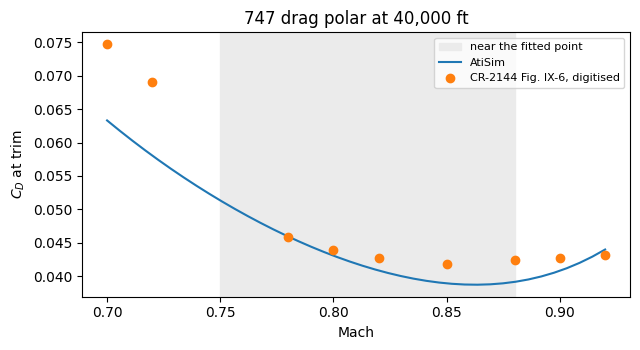

In [5]:
# The digitised figure, the tolerances, and the function that trims the 747 at a
# Mach number and returns its drag coefficient -- all exactly as the suite uses them.
from atisim.tests.test_drag_polar import _NEAR_FIT_TOL, _OFF_FIT_TOL, FIGURE_IX6_40KFT
from atisim.tests.test_drag_polar import _sim_cd as model_cd

machs = sorted(FIGURE_IX6_40KFT)
cd_model = [model_cd(m) for m in machs]
print(f"{'Mach':>6}{'figure':>9}{'model':>9}{'error':>9}   band")
for m, cd in zip(machs, cd_model):
    near = 0.75 <= m <= 0.88
    print(f"{m:6.2f}{FIGURE_IX6_40KFT[m]:9.4f}{cd:9.4f}{cd - FIGURE_IX6_40KFT[m]:+9.4f}   "
          f"{'near the fit' if near else 'extrapolated'}")
    assert abs(cd - FIGURE_IX6_40KFT[m]) <= (_NEAR_FIT_TOL if near else _OFF_FIT_TOL)

fine = np.linspace(machs[0], machs[-1], 40)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.axvspan(0.75, 0.88, color="0.92", label="near the fitted point")
ax.plot(fine, [model_cd(m) for m in fine], label="AtiSim")
ax.plot(machs, [FIGURE_IX6_40KFT[m] for m in machs], "o", label="CR-2144 Fig. IX-6, digitised")
ax.set_xlabel("Mach"); ax.set_ylabel("$C_D$ at trim"); ax.legend(fontsize=8)
ax.set_title("747 drag polar at 40,000 ft")
fig.tight_layout()

### Against an independent engine: JSBSim's 737

Everything above tests the model against the arithmetic of the document its data came from.
JSBSim is different code — a mature open-source flight dynamics engine — and fed the same
737 coefficients, the two engines should reach the same trim and the same modes. JSBSim's
results are frozen in `atisim/tests/data/`, so JSBSim itself does not need to be installed.

This checks the *code*, not the aircraft: JSBSim's 737 is built from public data and
estimates, and nothing here claims it is a correct 737.

In [6]:
ref = jsbsim_ref.load()
cond, jsb_trim = ref.condition["cruise"], ref.trim["longitudinal"]
b737 = REGISTRY["boeing737"]

x, _ = trim.trim(jnp.array(cond.airspeed), jnp.array(cond.matched_altitude), b737)
a737, de737, thr737 = (float(v) for v in x)
print(f"JSBSim {ref.jsbsim_version.split()[0]}, 737 at {cond.airspeed:.1f} m/s\n")
print(f"{'':26}{'AtiSim':>11}{'JSBSim':>11}")
print(f"{'trim alpha, deg':26}{a737 * RAD2DEG:11.4f}{jsb_trim.alpha * RAD2DEG:11.4f}")
print(f"{'trim elevator, deg':26}{de737 * RAD2DEG:11.4f}{jsb_trim.elevator * RAD2DEG:11.4f}")

ours = validation.longitudinal_modes(b737, a737, de737, thr737, cond.airspeed, cond.matched_altitude)
theirs = validation.modes_from_matrix(ref.linearization.longitudinal)
for mode, (wn, z), (wn_j, z_j) in zip(("phugoid", "short period"), ours, theirs):
    print(f"{mode + ' frequency, rad/s':26}{wn:11.4f}{wn_j:11.4f}")
    print(f"{mode + ' damping':26}{z:11.4f}{z_j:11.4f}")

# The tolerances test_jsbsim_737_layers.py asserts (layers 2 and 3).
assert abs(a737 - jsb_trim.alpha) < 5e-4 and abs(de737 - jsb_trim.elevator) < 2e-3
for (wn, z), (wn_j, z_j), tol in zip(ours, theirs, (0.10, 0.02)):
    assert abs(wn / wn_j - 1) < tol and abs(z / z_j - 1) < tol

JSBSim 1.3.1, 737 at 236.5 m/s

                               AtiSim     JSBSim
trim alpha, deg                1.9672     1.9650
trim elevator, deg            -3.0397    -2.9749


phugoid frequency, rad/s       0.0526     0.0524
phugoid damping                0.0546     0.0554
short period frequency, rad/s     1.7681     1.7692
short period damping           0.3932     0.3929


Both modes agree. The phugoid is the harder of the two: its frequency depends on how the
pitching moment changes with speed, and it matched only once the model read the Mach schedule
of the elevator's power from JSBSim's own 737 file instead of holding it constant
(`docs/PROJECT.md` §4).

## Rung 3 — a real encounter: Hannibal, Missouri, 3 April 1981

A DC-10 at 37,000 ft flew through a row of clear-air-turbulence vortices. NASA identified the
wind field from its flight recorder — Mehta (1987) fitted five vortices to it — and
TM-102186 records the normal load the aircraft pulled.

The model flies a Boeing 747 through Mehta's field, replayed along the path it was identified
on. **It is not the same aircraft:** no DC-10 derivative set is published, and the DC-10's
weight on the day was not recorded. So the load is not expected to match, and it does not.
The shortfall is the result, not a defect to tune away; the status table on the documentation
site's *Validation* page lists what is known about it.

In [7]:
enc, meta = cat_validation.fly_mehta("boeing747", dt=0.01, replayed=True)
lo, hi = wind.TM102186_HANNIBAL_NZ
fraction = (enc.n_z.max() - enc.n_z.min()) / (hi - lo)

print(f"vertical gust met       {enc.w_up.min() / FT2M:+6.1f} to {enc.w_up.max() / FT2M:+6.1f} ft/s")
print(f"load, AtiSim 747        {enc.n_z.min():+6.3f} to {enc.n_z.max():+6.3f} g")
print(f"load, DC-10 recorded    {lo:+6.3f} to {hi:+6.3f} g   (TM-102186)")
print(f"peak-to-peak reached    {fraction:.1%} of the record")

# The envelope the claim is made inside, checked on this run rather than assumed.
band = checks.recovery_band(enc.log, meta["ac"])
alpha = checks.alpha_band(enc.log, meta["field"], enc.window)
print(f"\nrecovery band: {band.detail}")
print(f"incidence:     |alpha| peaks at {alpha.window_deg:.2f} deg in the encounter "
      f"(linear aerodynamics to {ALPHA_LINEAR_DEG:.0f} deg)")

assert band.passed and alpha.window_deg < ALPHA_LINEAR_DEG
# The record's two features the model does reproduce: the load goes negative,
# and it exceeds 1 g on the other side. And the one it does not: the size.
assert enc.n_z.min() < 0.0 < 1.0 < enc.n_z.max()
assert fraction < 1.0

vertical gust met        -87.1 to  +87.8 ft/s
load, AtiSim 747        -0.415 to +1.619 g
load, DC-10 recorded    -1.000 to +1.700 g   (TM-102186)
peak-to-peak reached    75.3% of the record



recovery band: inside the recovery condition: Mach 0.748-0.834 against [0.7, 0.9]; altitude 11278-11511 m against [10668, 13716].
incidence:     |alpha| peaks at 8.03 deg in the encounter (linear aerodynamics to 10 deg)


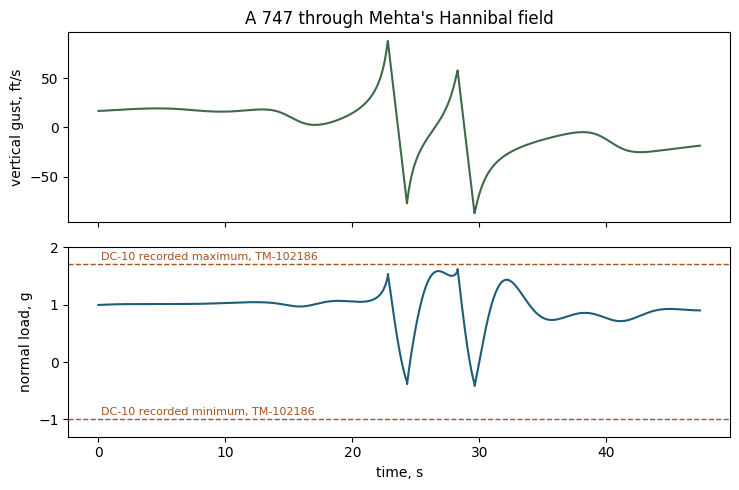

In [8]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(7.5, 5), sharex=True)
top.plot(enc.t, enc.w_up / FT2M, color="#3E6A48")
top.set_ylabel("vertical gust, ft/s")
top.set_title("A 747 through Mehta's Hannibal field")
bottom.plot(enc.t, enc.n_z, color="#1D5D77", label="AtiSim 747")
for level, text in ((lo, "recorded minimum"), (hi, "recorded maximum")):
    bottom.axhline(level, ls="--", color="#A9501C", lw=1)
    bottom.annotate(f"DC-10 {text}, TM-102186", (enc.t[0], level), xytext=(2, 3),
                    textcoords="offset points", fontsize=8, color="#A9501C")
bottom.set_ylabel("normal load, g")
bottom.set_xlabel("time, s")
bottom.set_ylim(lo - 0.3, hi + 0.3)
fig.tight_layout()

## Rung 4 — the orderings, and the mechanism behind them

This is where the claim lives. An absolute load needs the right aircraft; an ordering needs
only the right physics.

### TM-102186 Fig. 8: three aircraft through the same vortices

TM-102186 flies three aircraft of very different speed through one vortex array. The slow one
pitches hugely and pulls the mildest load; the fast one barely pitches and pulls the worst.
The paper's explanation: a slow aircraft takes several of its own short periods to cross a
core, so it has time to pitch into the flow and shed the gust before it reaches the wing.

The model flies six aircraft through Mehta's field. The Cherokee stands in for the paper's
remotely piloted vehicle and the 747 for its airliner. The paper's executive jet has no
counterpart in the registry and is left out rather than substituted. The mechanism is tested
directly by the **incidence gain**: the angle of attack that actually reached the wing,
divided by the one a rigidly held attitude would have seen. Below 1, the aircraft shed part of
the gust; above 1, its own motion added to it.

In [9]:
fleet = {}
for name in cat_validation.MECHANISM_FLEET:
    e, m = cat_validation.fly_mehta(name, dt=0.01)
    fleet[name] = dict(cat_validation.excursion(e, m["V"]),
                       ratio=cat_validation.traverse_ratio(name, m["r0"]))

print(f"{'aircraft':20}{'core crossing /':>16}{'pitch':>9}{'load':>9}{'incidence':>11}{'|alpha|':>9}")
print(f"{'':20}{'short period':>16}{'p-p, deg':>9}{'min, g':>9}{'gain':>11}{'peak':>9}")
for name, r in sorted(fleet.items(), key=lambda kv: kv[1]["ratio"]):
    print(f"{name:20}{r['ratio']:16.3f}{r['pitch_ptp']:9.2f}{r['g_min']:+9.3f}"
          f"{r['incidence_gain']:11.2f}{r['alpha_peak']:9.2f}")

# The test suite does not fly this fleet, so the assertions below are this
# claim's only gate -- which is why CI runs the notebook.
slow, fast = fleet["cherokee"], fleet["boeing747"]
assert slow["pitch_ptp"] > fast["pitch_ptp"], "the slow aircraft should pitch more"
assert slow["g_min"] > fast["g_min"], "...and pull the milder load"

# The mechanism: the longer a core crossing lasts in short periods, the more of
# the gust the aircraft sheds. Monotonic across the whole fleet, no exceptions.
gains = [r["incidence_gain"] for r in sorted(fleet.values(), key=lambda r: r["ratio"])]
assert all(a > b for a, b in zip(gains, gains[1:])), gains
# And the mechanism is also why every run stays inside the linear aerodynamics.
assert all(r["alpha_peak"] < ALPHA_LINEAR_DEG for r in fleet.values())

aircraft             core crossing /    pitch     load  incidence  |alpha|
                        short period p-p, deg   min, g       gain     peak
boeing747                      0.196     7.01   -0.372       1.55     7.25
boeing737                      0.363     7.49   -0.364       0.98     5.24
boeing747_approach             0.512    40.08   +0.069       0.57     9.78
boeing737_approach             0.599    16.71   -0.145       0.55     7.05
cherokee                       4.024    47.00   +0.402       0.21     5.44
cessna172                      4.046    74.93   +0.413       0.18     5.50


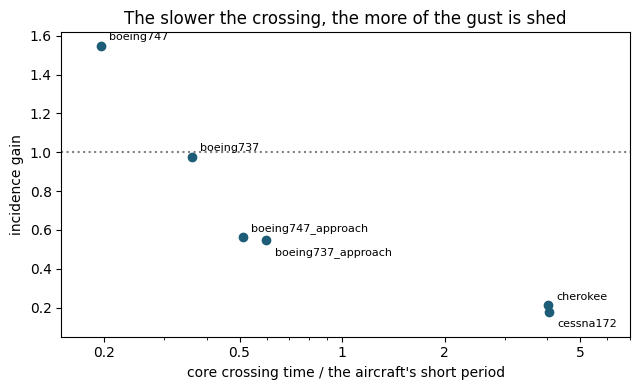

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
below = {"boeing737_approach", "cessna172"}  # labelled underneath, clear of a close neighbour
for name, r in fleet.items():
    ax.plot(r["ratio"], r["incidence_gain"], "o", color="#1D5D77")
    ax.annotate(name, (r["ratio"], r["incidence_gain"]),
                xytext=(6, -11 if name in below else 4),
                textcoords="offset points", fontsize=8)
ax.axhline(1.0, ls=":", color="0.5")
ax.set_xscale("log")
ax.set_xticks([0.2, 0.5, 1, 2, 5], labels=["0.2", "0.5", "1", "2", "5"])
ax.set_xlim(0.15, 7)
ax.set_ylim(0.05, None)
ax.set_xlabel("core crossing time / the aircraft's short period")
ax.set_ylabel("incidence gain")
ax.set_title("The slower the crossing, the more of the gust is shed")
fig.tight_layout()

### Wingrove & Bach Fig. 8: vortex, updraft or manoeuvre?

Wingrove & Bach separate three causes of a large load by how much the aircraft pitches while
it pulls it. A vortex core is crossed in a fraction of a short period, so the load arrives
before the attitude can follow; an updraft lasts long enough for the aircraft to pitch with
it; a pilot's manoeuvre pitches the aircraft deliberately. `scripts/vortex.py` flies the 747
through all three and checks that the pitch excursions fall in that order.

vortex (hannibal)      window=first core             d(theta)= 2.333 deg  d(n)=-1.246 g  n_z(0)=1.0315  |alpha|max= 8.23 deg linear
updraft                window=column                 d(theta)= 4.267 deg  d(n)=-0.083 g  n_z(0)=0.9929  |alpha|max= 6.09 deg linear
manoeuvre              window=elevator pulse, 6.609 s d(theta)=30.106 deg  d(n)=-1.900 g  n_z(0)=0.9929  |alpha|max=10.29 deg MARGINAL

Fig. 8 pitch excursion, deg:  paper [1.4, 6.2, 12.0]  model [2.33, 4.27, 30.11]
ordering vortex < updraft < manoeuvre: HOLDS   (ordering is the claim; absolute agreement is forbidden by section 5)


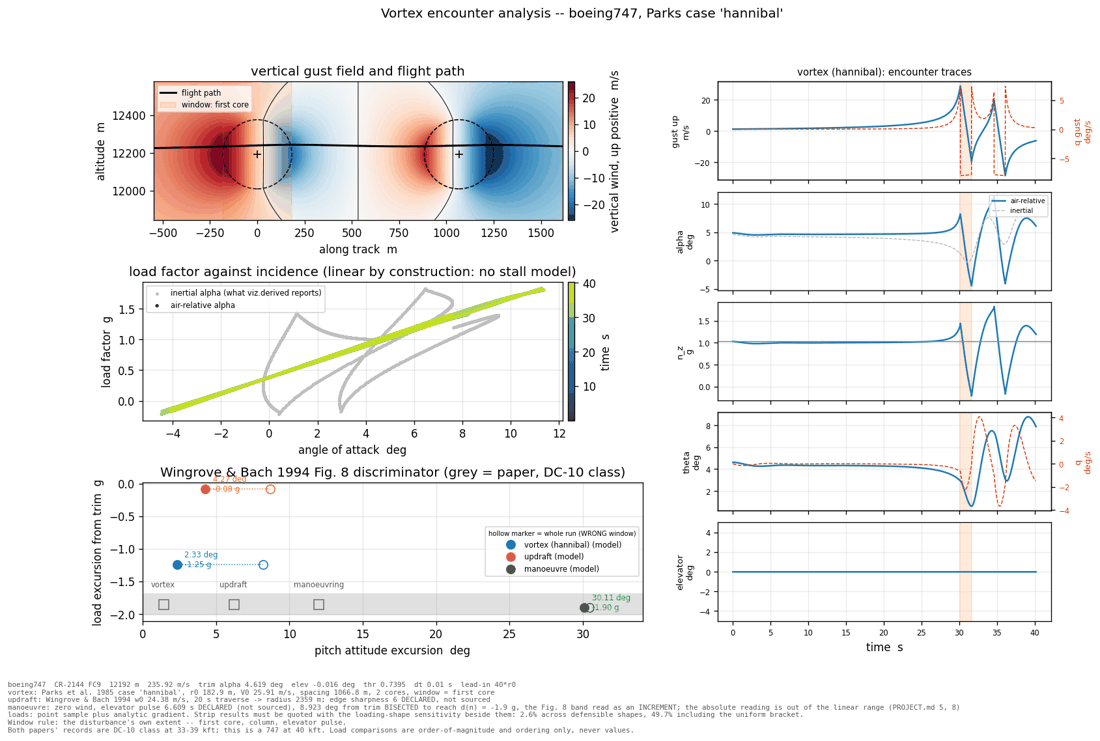

In [11]:
png = Path(tempfile.mkdtemp()) / "fig8.png"
out = run_script("vortex.py", "--case", "hannibal", "--png", str(png))
print("\n".join(line for line in out.splitlines() if not line.startswith("wrote ")))
assert "ordering vortex < updraft < manoeuvre: HOLDS" in out

# Shown at screen size rather than print size, so the saved notebook stays small.
figure = PIL.Image.open(png).convert("RGB")
figure.thumbnail((1100, 1100))
buffer = io.BytesIO()
figure.quantize(256).save(buffer, "PNG", optimize=True)
display(Image(data=buffer.getvalue()))

## What this establishes, and what it does not

**Established.** The model gets hand-derived answers right; it reproduces the natural modes
and drag polar of its own source data, with each disagreement attributed; an independent
engine fed the same coefficients reaches the same trim and modes; and flown through a
recorded encounter it reproduces both published orderings and the mechanism behind them.

**Not established, and not claimed.** That it predicts the load an aircraft will pull: rung 3
falls short of the record and the aircraft is not the one that flew it. Behaviour outside the
envelope rung 3 checks — other aircraft, other speeds and heights, angles of attack past the
linear range, lateral response. The full claim, the envelope it holds inside and the status of
every known gap are on the documentation site's *Validation* page, drawn from
[`docs/PROJECT.md`](../docs/PROJECT.md).